# GIPCA Asset Pricing

This notebook applies **Generalized Instrumented PCA (GIPCA)** to US stock returns,
following the methodology from Kelly, Pruitt & Su (2020).

**Model:**
- Cross-sectional: $r_{i,t+1} = z_{i,t}' \Gamma f_{t+1} + \epsilon_{i,t+1}$
- Factor dynamics: $f_t = \Lambda' m_t + \nu_t$

**Data:**
- CRSP monthly returns (1965–2018)
- 94 firm characteristics (Gu et al. 2020)
- Welch & Goyal macro predictors

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sys.path.insert(0, '../src')
from generalized_ipca import GIPCA
from als_ipca import ALSIPCA

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## Load & Prepare Returns

In [2]:
# Load CRSP monthly returns (only needed columns)
returns_df = pd.read_csv(
    '../data/crsp_monthly_returns.csv',
    usecols=['PERMNO', 'YYYYMM', 'MthRet', 'MthCap'],
    dtype={'PERMNO': np.int64, 'YYYYMM': np.int64, 'MthRet': np.float32, 'MthCap': np.float64}
)

# Filter to 1965-2018
returns_df = returns_df[(returns_df['YYYYMM'] >= 196501) & (returns_df['YYYYMM'] <= 201812)].copy()

# Drop missing returns
returns_df.dropna(subset=['MthRet'], inplace=True)

print(f"Returns: {returns_df.shape[0]:,} obs, "
      f"{returns_df['PERMNO'].nunique():,} stocks, "
      f"{returns_df['YYYYMM'].nunique()} months")
print(f"Date range: {returns_df['YYYYMM'].min()} - {returns_df['YYYYMM'].max()}")
returns_df.head()

Returns: 3,823,690 obs, 31,033 stocks, 624 months
Date range: 196501 - 201612


,PERMNO,YYYYMM,MthCap,MthRet
0,10000,198601,16100.00,0.707317
1,10000,198602,11960.00,-0.257143
2,10000,198603,16330.00,0.365385
3,10000,198604,15172.00,-0.098592
4,10000,198605,11793.86,-0.222656


## Load & Prepare Characteristics

In [3]:
# Load datashare characteristics
chars_df = pd.read_csv('../data/datashare.csv', dtype={'permno': np.int64, 'DATE': np.int64})

# Align column names - DATE is YYYYMMDD format, convert to YYYYMM
chars_df.rename(columns={'permno': 'PERMNO'}, inplace=True)
chars_df['YYYYMM'] = chars_df['DATE'] // 100  # Convert YYYYMMDD to YYYYMM
chars_df.drop(columns=['DATE'], inplace=True)

# Filter to 1965-2018
chars_df = chars_df[(chars_df['YYYYMM'] >= 196501) & (chars_df['YYYYMM'] <= 201812)].copy()

# Identify characteristic columns (everything except PERMNO and YYYYMM)
char_cols = [c for c in chars_df.columns if c not in ['PERMNO', 'YYYYMM']]
print(f"Number of characteristics: {len(char_cols)}")

# Cross-sectional rank transform to [-0.5, 0.5] each month
print("Rank-transforming characteristics...")
chars_df[char_cols] = (
    chars_df.groupby('YYYYMM')[char_cols].rank(pct=True) - 0.5
)

# Fill NaN with 0 (cross-sectional median after ranking)
chars_df[char_cols] = chars_df[char_cols].fillna(0).astype(np.float32)

print(f"Characteristics: {chars_df.shape[0]:,} obs, "
      f"{chars_df['PERMNO'].nunique():,} stocks")
print(f"Date range: {chars_df['YYYYMM'].min()} - {chars_df['YYYYMM'].max()}")
chars_df.head()

Number of characteristics: 95
Rank-transforming characteristics...


Characteristics: 3,629,074 obs, 29,573 stocks
Date range: 196501 - 201612


,PERMNO,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,mom6m,...,ms,baspread,ill,maxret,retvol,std_dolvol,std_turn,zerotrade,sic2,YYYYMM
131134,10006,0.336011,-0.109399,-0.109399,-0.110695,0.372918,-0.202880,0.365203,-0.284630,0.274940,...,0.0,0.033050,-0.397776,-0.213881,-0.038026,-0.333649,0.058810,-0.206717,0.104570,196501
131135,10014,-0.260397,-0.291814,-0.291814,-0.050725,-0.188244,0.202375,0.012984,0.108159,-0.348193,...,0.0,0.477809,0.346190,0.435788,0.451346,0.183886,0.331365,-0.265374,0.170411,196501
131136,10030,0.241021,-0.308489,-0.308489,0.151674,0.152546,-0.421678,0.012984,0.172676,0.156867,...,0.0,-0.477809,-0.250118,-0.452786,-0.457959,0.034123,-0.176429,-0.036424,0.104570,196501
131137,10057,0.022684,0.017433,0.017433,-0.192154,0.133984,-0.291309,0.012984,-0.124288,0.078313,...,0.0,-0.215770,-0.076905,0.250708,0.134861,0.327488,0.305385,-0.261589,-0.019365,196501
131138,10065,0.226371,0.031582,0.031582,0.196152,0.028320,-0.493431,0.392351,0.204459,0.127952,...,0.0,-0.280453,-0.123284,-0.300755,-0.204771,0.129384,-0.165564,0.017029,0.000000,196501


## Load & Prepare Macro Variables

In [4]:
# Load Welch & Goyal macro predictors
macro_df = pd.read_csv('../data/macro/PredictorData2021 - Monthly.csv')

# Rename date column for consistency
macro_df.rename(columns={'yyyymm': 'YYYYMM'}, inplace=True)
macro_df['YYYYMM'] = macro_df['YYYYMM'].astype(np.int64)

# Select usable macro predictors (exclude returns/levels)
macro_cols = ['D12', 'E12', 'b/m', 'tbl', 'ntis', 'infl', 'svar',
              'AAA', 'BAA', 'lty', 'corpr', 'csp', 'ltr']

# Keep only YYYYMM, Rfree (for excess returns), and macro predictors
available_macro = [c for c in macro_cols if c in macro_df.columns]
macro_df = macro_df[['YYYYMM', 'Rfree'] + available_macro].copy()

# Filter to 1965-2018
macro_df = macro_df[(macro_df['YYYYMM'] >= 196501) & (macro_df['YYYYMM'] <= 201812)].copy()

# Forward-fill then drop remaining NaN
macro_df[available_macro] = macro_df[available_macro].ffill()
macro_df.dropna(subset=available_macro, inplace=True)

# Standardize macro variables (z-score)
macro_means = macro_df[available_macro].mean()
macro_stds = macro_df[available_macro].std()
macro_df[available_macro] = (macro_df[available_macro] - macro_means) / macro_stds

print(f"Macro variables: {len(available_macro)} predictors, {len(macro_df)} months")
print(f"Predictors used: {available_macro}")
macro_df.head()

Macro variables: 13 predictors, 648 months
Predictors used: ['D12', 'E12', 'b/m', 'tbl', 'ntis', 'infl', 'svar', 'AAA', 'BAA', 'lty', 'corpr', 'csp', 'ltr']


,YYYYMM,Rfree,D12,E12,b/m,tbl,ntis,infl,svar,AAA,BAA,lty,corpr,csp,ltr
1128,196501,0.0028,-1.002961,-0.954659,-0.064800,-0.281375,0.422436,-0.892557,-0.455603,-1.137080,-1.283866,-0.870014,0.066849,-0.176828,-0.072803
1129,196502,0.0030,-1.001621,-0.953308,-0.066011,-0.244606,0.270280,-0.892557,-0.404430,-1.144818,-1.290972,-0.862698,-0.202186,-0.177372,-0.158927
1130,196503,0.0036,-1.000273,-0.951960,-0.073153,-0.244606,0.483213,-0.007088,-0.460372,-1.140949,-1.290972,-0.870014,-0.190976,-0.143465,-0.026428
1131,196504,0.0031,-0.998659,-0.950301,-0.136478,-0.244606,0.265306,-0.009917,-0.456290,-1.137080,-1.283866,-0.870014,-0.157347,-0.146416,-0.086053
1132,196505,0.0031,-0.997045,-0.948638,-0.128605,-0.256862,0.340506,-0.892557,-0.417805,-1.133210,-1.280313,-0.866356,-0.265708,-0.368911,-0.145677


## Panel Construction

In [5]:
# Inner-merge returns and characteristics
panel = returns_df.merge(chars_df, on=['PERMNO', 'YYYYMM'], how='inner')
print(f"Merged panel: {panel.shape[0]:,} obs")

# Free memory
del returns_df, chars_df

# Select top 100 stocks by average market cap (fast execution while representative)
avg_cap = panel.groupby('PERMNO')['MthCap'].mean()
top_stocks = avg_cap.nlargest(100).index
panel = panel[panel['PERMNO'].isin(top_stocks)].copy()
print(f"After filtering to top 100 stocks: {panel.shape[0]:,} obs")

# Merge Rfree for excess returns
panel = panel.merge(macro_df[['YYYYMM', 'Rfree']], on='YYYYMM', how='inner')
panel['ExRet'] = panel['MthRet'] - panel['Rfree'].astype(np.float32)

# Keep only months present in macro data
common_months = sorted(set(panel['YYYYMM'].unique()) & set(macro_df['YYYYMM'].unique()))
panel = panel[panel['YYYYMM'].isin(common_months)].copy()

# Build arrays: pivot to (T, N) and (T, N, L)
months = sorted(panel['YYYYMM'].unique())
stocks = sorted(panel['PERMNO'].unique())
T, N = len(months), len(stocks)
L = len(char_cols)

month_idx = {m: i for i, m in enumerate(months)}
stock_idx = {s: i for i, s in enumerate(stocks)}

# Initialize arrays with NaN
returns_arr = np.full((T, N), np.nan, dtype=np.float32)
chars_arr = np.zeros((T, N, L), dtype=np.float32)

# Fill arrays vectorized
panel['t_idx'] = panel['YYYYMM'].map(month_idx)
panel['n_idx'] = panel['PERMNO'].map(stock_idx)

t_indices = panel['t_idx'].values.astype(int)
n_indices = panel['n_idx'].values.astype(int)
returns_arr[t_indices, n_indices] = panel['ExRet'].values.astype(np.float32)
chars_arr[t_indices, n_indices, :] = panel[char_cols].values.astype(np.float32)

# Macro array (aligned to months)
macro_aligned = macro_df[macro_df['YYYYMM'].isin(months)].sort_values('YYYYMM')
macro_arr = macro_aligned[available_macro].values.astype(np.float32)

print(f"\nFinal arrays:")
print(f"  Returns: {returns_arr.shape} (T={T}, N={N})")
print(f"  Characteristics: {chars_arr.shape} (T={T}, N={N}, L={L})")
print(f"  Macro: {macro_arr.shape} (T={T}, R={len(available_macro)})")
print(f"  Non-NaN returns: {np.sum(~np.isnan(returns_arr)):,} / {T*N:,} "
      f"({100*np.sum(~np.isnan(returns_arr))/(T*N):.1f}%)")

# Free panel DataFrame
del panel

Merged panel: 3,663,604 obs
After filtering to top 100 stocks: 31,050 obs

Final arrays:
  Returns: (624, 100) (T=624, N=100)
  Characteristics: (624, 100, 95) (T=624, N=100, L=95)
  Macro: (624, 13) (T=624, R=13)
  Non-NaN returns: 30,873 / 62,400 (49.5%)


## Train/Test Split

In [6]:
# In-sample: 1965-2004, Out-of-sample: 2005-2018
split_date = 200412
split_idx = next(i for i, m in enumerate(months) if m > split_date)

train_returns = returns_arr[:split_idx]
train_chars = chars_arr[:split_idx]
train_macro = macro_arr[:split_idx]

test_returns = returns_arr[split_idx:]
test_chars = chars_arr[split_idx:]
test_macro = macro_arr[split_idx:]

print(f"Train: {split_idx} months ({months[0]} - {months[split_idx-1]})")
print(f"Test:  {T - split_idx} months ({months[split_idx]} - {months[-1]})")

Train: 480 months (196501 - 200412)
Test:  144 months (200501 - 201612)


## Fit GIPCA Model

In [7]:
# Fill NaN with 0 for GIPCA (consistent with ALSIPCA)
train_returns_filled = np.nan_to_num(train_returns, nan=0.0)

# Get dimensions
T_train, N_train = train_returns.shape
R = len(available_macro)
K = 4  # Number of factors

model = GIPCA(
    num_assets=N_train,
    num_fact=K,
    num_charact=L,
    num_macro=R,
    win_len=T_train,
    alpha=1.0
)

# Fit model: data = [returns, characteristics, macro]
Gamma_est, history = model.fit(
    data=[train_returns_filled, train_chars, train_macro],
    max_iter=100,
    tol=1e-4,
    verbose=True,
    seed=42
)

# Extract factors (K x T) -> transpose to (T x K) for consistency
train_factors = model.factors.values.T

print(f"\nConverged in {model.n_iterations} iterations")
print(f"Estimated factors shape: {train_factors.shape}")
print(f"Gamma shape: {model.Gamma.shape}")
print(f"Lambda shape: {model.Lambda.shape}")

Iteration    0: Objective = 4.473836


Iteration   10: Objective = 2.011891, Max change = 1.35e+00


Iteration   20: Objective = 1.868570, Max change = 1.29e+00


Iteration   30: Objective = 1.888981, Max change = 7.56e-01


Iteration   40: Objective = 2.009831, Max change = 1.27e+00


...

Iteration   60: Objective = 1.719245, Max change = 1.40e-01


Iteration   70: Objective = 1.846853, Max change = 8.10e-01


Iteration   80: Objective = 1.951338, Max change = 7.24e-01


Iteration   90: Objective = 1.866066, Max change = 7.82e-01


Iteration  100: Objective = 1.717669, Max change = 7.29e-01

Converged in 100 iterations
Estimated factors shape: (480, 4)
Gamma shape: (95, 4)
Lambda shape: (13, 4)


## In-Sample Evaluation

In [8]:
# Get Gamma and Lambda as numpy arrays
Gamma_arr = model.Gamma.values
Lambda_arr = model.Lambda.values

# In-sample total R²: predict with realized factors
train_pred = np.zeros_like(train_returns_filled)
for t in range(T_train):
    train_pred[t, :] = train_chars[t] @ Gamma_arr @ train_factors[t]

mask_train = ~np.isnan(train_returns)
ss_res_train = np.sum((train_returns[mask_train] - train_pred[mask_train])**2)
ss_tot_train = np.sum((train_returns[mask_train] - np.nanmean(train_returns))**2)
r2_total_train = 1 - ss_res_train / ss_tot_train

# Predictive R² (using macro-predicted factors)
predicted_factors_train = train_macro @ Lambda_arr  # T x K
train_pred_macro = np.zeros_like(train_returns_filled)
for t in range(T_train):
    train_pred_macro[t, :] = train_chars[t] @ Gamma_arr @ predicted_factors_train[t]

ss_res_pred_train = np.sum((train_returns[mask_train] - train_pred_macro[mask_train])**2)
r2_pred_train = 1 - ss_res_pred_train / ss_tot_train

print(f"In-Sample Results:")
print(f"  Total R²:      {r2_total_train:.4f} ({r2_total_train*100:.2f}%)")
print(f"  Predictive R²:  {r2_pred_train:.4f} ({r2_pred_train*100:.2f}%)")

# Macro R² per factor
macro_r2 = model.factor_macro_r2()
print(f"\nMacro R² per factor: {np.round(macro_r2, 4)}")

# Top characteristics per factor (Gamma summary)
print(f"\nTop 5 characteristics per factor (by |Gamma|):")
for k in range(K):
    gamma_k = np.abs(Gamma_arr[:, k])
    top_idx = np.argsort(gamma_k)[-5:][::-1]
    top_chars = [(char_cols[i], Gamma_arr[i, k]) for i in top_idx]
    print(f"  Factor {k+1}: {', '.join(f'{name} ({val:+.3f})' for name, val in top_chars)}")

In-Sample Results:
  Total R²:      0.0951 (9.51%)
  Predictive R²:  0.0464 (4.64%)

Macro R² per factor: [0.9946 0.9139 0.9974 0.903 ]

Top 5 characteristics per factor (by |Gamma|):
  Factor 1: dolvol (+0.492), lev (+0.378), ill (+0.254), pchsale_pchinvt (+0.206), mvel1 (-0.191)
  Factor 2: beta (-0.600), betasq (+0.560), mvel1 (-0.355), ill (-0.202), zerotrade (+0.181)
  Factor 3: pchsale_pchinvt (+0.328), mvel1 (-0.297), pchsaleinv (-0.287), divi (-0.266), zerotrade (+0.209)
  Factor 4: mvel1 (-0.396), bm (+0.308), betasq (-0.302), cfp (+0.270), zerotrade (+0.257)


## Out-of-Sample Evaluation

In [9]:
# OOS prediction using macro-predicted factors
test_returns_filled = np.nan_to_num(test_returns, nan=0.0)
T_test = test_returns.shape[0]

# Macro-predicted factors
test_factors_macro = test_macro @ Lambda_arr  # T_test x K
test_pred = np.zeros_like(test_returns_filled)
for t in range(T_test):
    test_pred[t, :] = test_chars[t] @ Gamma_arr @ test_factors_macro[t]

mask_test = ~np.isnan(test_returns)
ss_res_test = np.sum((test_returns[mask_test] - test_pred[mask_test])**2)
ss_tot_test = np.sum((test_returns[mask_test] - np.nanmean(test_returns))**2)
r2_total_oos = 1 - ss_res_test / ss_tot_test

# OOS with realized factors (upper bound) - estimate via cross-sectional regression
test_factors = np.zeros((T_test, K), dtype=np.float32)
for t in range(T_test):
    loadings_t = test_chars[t] @ Gamma_arr  # (N, K)
    f_t, *_ = np.linalg.lstsq(loadings_t, test_returns_filled[t], rcond=None)
    test_factors[t] = f_t

test_pred_realized = np.zeros_like(test_returns_filled)
for t in range(T_test):
    test_pred_realized[t, :] = test_chars[t] @ Gamma_arr @ test_factors[t]

ss_res_test_realized = np.sum((test_returns[mask_test] - test_pred_realized[mask_test])**2)
r2_total_oos_realized = 1 - ss_res_test_realized / ss_tot_test

print(f"Out-of-Sample Results:")
print(f"  Total R² (macro-predicted factors): {r2_total_oos:.4f} ({r2_total_oos*100:.2f}%)")
print(f"  Total R² (realized factors):        {r2_total_oos_realized:.4f} ({r2_total_oos_realized*100:.2f}%)")
print(f"\nComparison:")
print(f"  IS Total R²:   {r2_total_train*100:.2f}%")
print(f"  OOS Total R²:  {r2_total_oos_realized*100:.2f}%")
print(f"  IS Pred R²:    {r2_pred_train*100:.2f}%")
print(f"  OOS Pred R²:   {r2_total_oos*100:.2f}%")

Out-of-Sample Results:
  Total R² (macro-predicted factors): 0.0151 (1.51%)
  Total R² (realized factors):        0.3694 (36.94%)

Comparison:
  IS Total R²:   9.51%
  OOS Total R²:  36.94%
  IS Pred R²:    4.64%
  OOS Pred R²:   1.51%


## Factor Analysis & Visualization

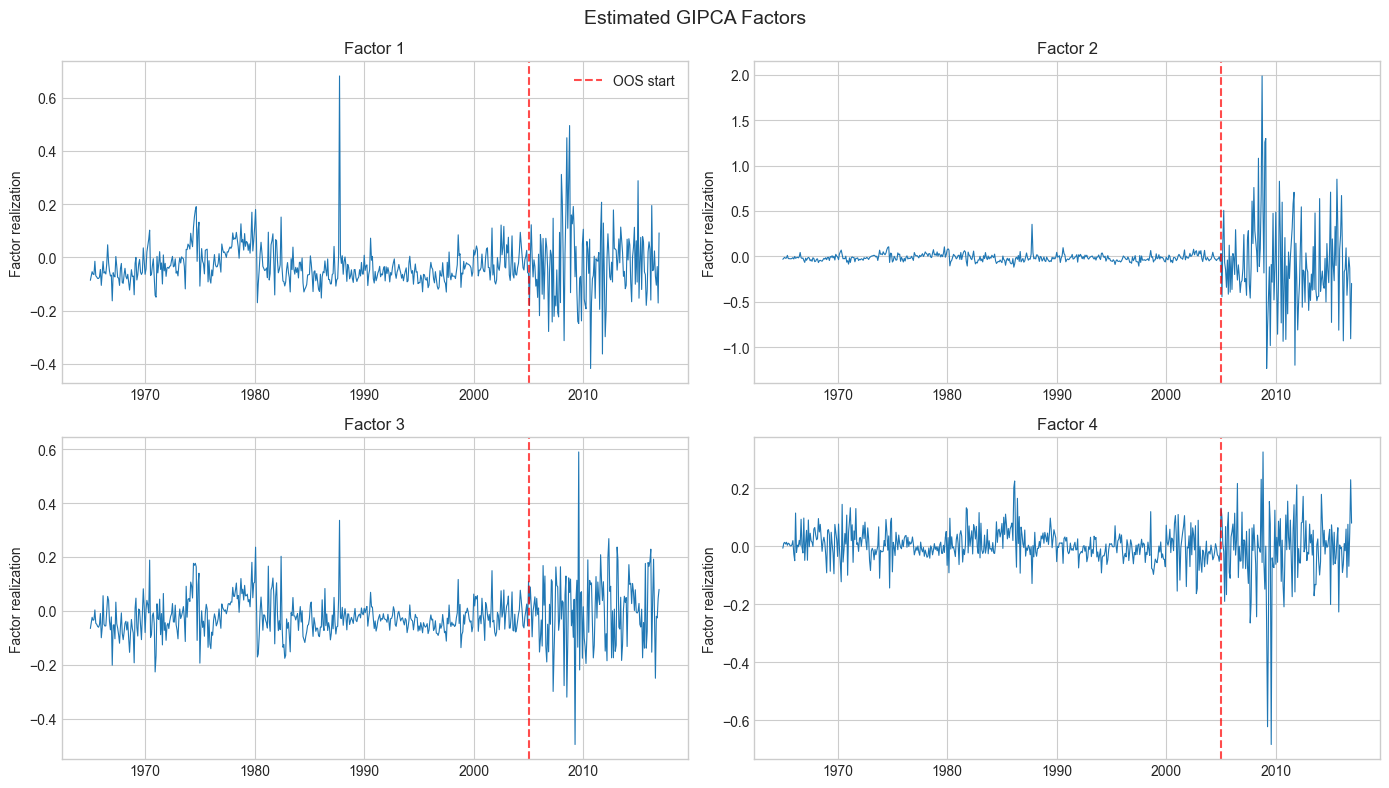

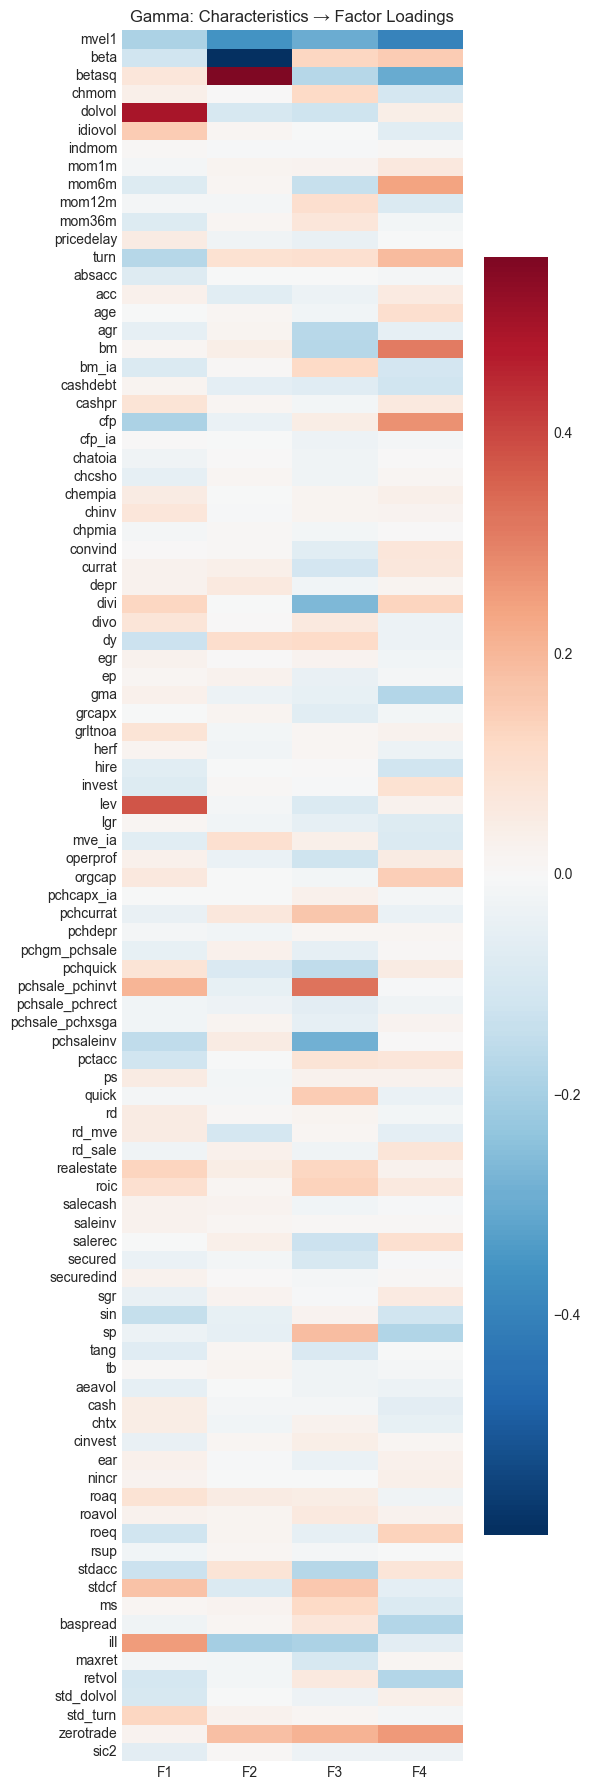

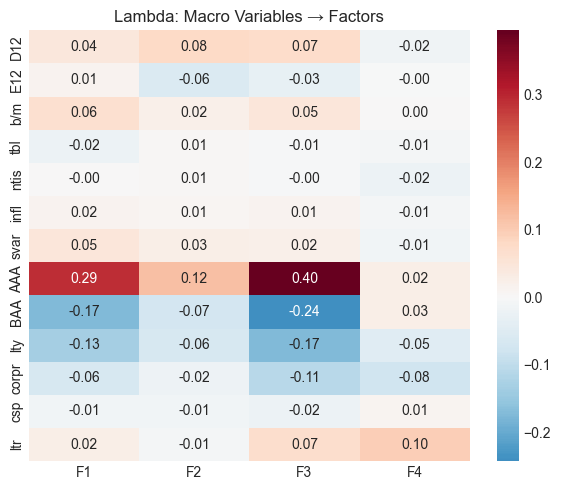

In [10]:
# Combine IS and OOS factors for full-sample view
all_factors = np.vstack([train_factors, test_factors])
all_dates = pd.to_datetime([str(m) for m in months], format='%Y%m')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for k, ax in enumerate(axes.flat):
    ax.plot(all_dates, all_factors[:, k], linewidth=0.8)
    ax.axvline(pd.Timestamp('2005-01-01'), color='red', linestyle='--', alpha=0.7, label='OOS start')
    ax.set_title(f'Factor {k+1}')
    ax.set_ylabel('Factor realization')
    if k == 0:
        ax.legend()
fig.suptitle('Estimated GIPCA Factors', fontsize=14)
plt.tight_layout()
plt.show()

# Gamma heatmap (characteristics -> factors)
fig, ax = plt.subplots(figsize=(6, 18))
sns.heatmap(
    pd.DataFrame(Gamma_arr, index=char_cols, columns=[f'F{k+1}' for k in range(K)]),
    cmap='RdBu_r', center=0, ax=ax,
    xticklabels=True, yticklabels=True
)
ax.set_title('Gamma: Characteristics → Factor Loadings')
plt.tight_layout()
plt.show()

# Lambda heatmap (macro -> factors)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    pd.DataFrame(Lambda_arr, index=available_macro, columns=[f'F{k+1}' for k in range(K)]),
    cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax
)
ax.set_title('Lambda: Macro Variables → Factors')
plt.tight_layout()
plt.show()

## Comparison: PCA vs IPCA vs GIPCA

In [11]:
# --- Standard PCA ---
pca = PCA(n_components=K)
pca.fit(train_returns_filled)

pca_train_pred = pca.inverse_transform(pca.transform(train_returns_filled))
ss_res_pca_train = np.sum((train_returns[mask_train] - pca_train_pred[mask_train])**2)
r2_pca_train = 1 - ss_res_pca_train / ss_tot_train

pca_test_pred = pca.inverse_transform(pca.transform(test_returns_filled))
ss_res_pca_test = np.sum((test_returns[mask_test] - pca_test_pred[mask_test])**2)
r2_pca_test = 1 - ss_res_pca_test / ss_tot_test

# --- IPCA (ALS) ---
ipca_model = ALSIPCA(
    num_assets=N_train,
    num_fact=K,
    num_charact=L,
    win_len=T_train
)

ipca_model.fit(
    data=[train_returns_filled, train_chars],
    max_iter=100,
    tol=1e-4,
    verbose=False
)

# In-sample IPCA
ipca_Gamma = ipca_model.Gamma.values
ipca_factors_train = ipca_model.factors.values  # K x T

ipca_train_pred = np.zeros_like(train_returns_filled)
for t in range(T_train):
    loadings_t = train_chars[t] @ ipca_Gamma
    ipca_train_pred[t] = loadings_t @ ipca_factors_train[:, t]

ss_res_ipca_train = np.sum((train_returns[mask_train] - ipca_train_pred[mask_train])**2)
r2_ipca_train = 1 - ss_res_ipca_train / ss_tot_train

# OOS IPCA with realized factors
ipca_test_pred = np.zeros_like(test_returns_filled)
for t in range(T_test):
    loadings_t = test_chars[t] @ ipca_Gamma
    f_t, *_ = np.linalg.lstsq(loadings_t, test_returns_filled[t], rcond=None)
    ipca_test_pred[t] = loadings_t @ f_t

ss_res_ipca_test = np.sum((test_returns[mask_test] - ipca_test_pred[mask_test])**2)
r2_ipca_test = 1 - ss_res_ipca_test / ss_tot_test

# OOS IPCA with mean factors
ipca_mean_factors = ipca_factors_train.mean(axis=1)
ipca_test_pred_mean = np.zeros_like(test_returns_filled)
for t in range(T_test):
    loadings_t = test_chars[t] @ ipca_Gamma
    ipca_test_pred_mean[t] = loadings_t @ ipca_mean_factors

ss_res_ipca_test_mean = np.sum((test_returns[mask_test] - ipca_test_pred_mean[mask_test])**2)
r2_ipca_test_mean = 1 - ss_res_ipca_test_mean / ss_tot_test

# --- Summary Table ---
print("Model Comparison (Total R²):")
print(f"{'Model':<30} {'In-Sample':>12} {'Out-of-Sample':>14}")
print("=" * 60)
print(f"{'PCA (4 factors)':<30} {r2_pca_train*100:>11.2f}% {r2_pca_test*100:>13.2f}%")
print(f"{'IPCA (realized f)':<30} {r2_ipca_train*100:>11.2f}% {r2_ipca_test*100:>13.2f}%")
print(f"{'IPCA (mean f, predictive)':<30} {'—':>12} {r2_ipca_test_mean*100:>13.2f}%")
print(f"{'GIPCA (realized f)':<30} {r2_total_train*100:>11.2f}% {r2_total_oos_realized*100:>13.2f}%")
print(f"{'GIPCA (macro-pred f)':<30} {r2_pred_train*100:>11.2f}% {r2_total_oos*100:>13.2f}%")
print("=" * 60)
print(f"\nPCA explained variance ratio: {np.round(pca.explained_variance_ratio_, 4)}")
print(f"IPCA converged in {ipca_model.n_iterations} iterations")
print(f"GIPCA converged in {model.n_iterations} iterations")

Model Comparison (Total R²):
Model                             In-Sample  Out-of-Sample
PCA (4 factors)                      45.23%         22.01%
IPCA (realized f)                    52.08%         42.40%
IPCA (mean f, predictive)                 —         -0.59%
GIPCA (realized f)                    9.51%         36.94%
GIPCA (macro-pred f)                  4.64%          1.51%

PCA explained variance ratio: [0.2377 0.1053 0.0459 0.0371]
IPCA converged in 100 iterations
GIPCA converged in 100 iterations


## Portfolio Analysis

Portfolio Sort Results (OOS, Annualized):
Quintile     Avg Return   Volatility   Sharpe
----------------------------------------------
Q1                7.06%       21.11%    0.33
Q2                5.29%       16.56%    0.32
Q3                8.81%       15.43%    0.57
Q4               14.24%       16.77%    0.85
Q5               21.00%       20.65%    1.02
----------------------------------------------
L/S (Q5-Q1)       13.95%       19.42%    0.72


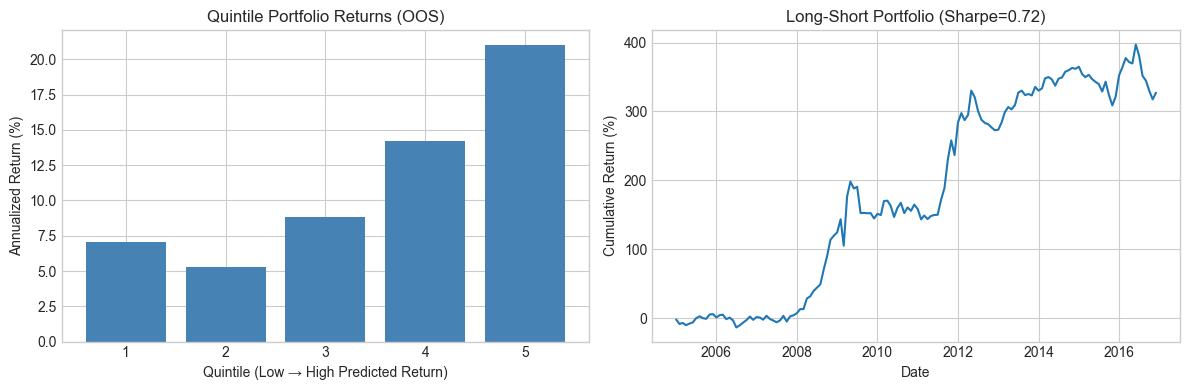

In [12]:
# Sort stocks into quintiles by predicted expected return (OOS)
n_quintiles = 5
oos_months = list(range(split_idx, T))

quintile_returns = {q: [] for q in range(n_quintiles)}

for t_rel, t_abs in enumerate(oos_months):
    preds_t = test_pred[t_rel, :]
    rets_t = test_returns[t_rel, :]
    
    # Only consider stocks with valid returns and predictions
    valid = ~np.isnan(rets_t) & ~np.isnan(preds_t)
    if valid.sum() < n_quintiles:
        continue
    
    preds_valid = preds_t[valid]
    rets_valid = rets_t[valid]
    
    # Assign quintiles based on predicted return
    quintile_breakpoints = np.percentile(preds_valid, np.linspace(0, 100, n_quintiles + 1))
    for q in range(n_quintiles):
        lb = quintile_breakpoints[q]
        ub = quintile_breakpoints[q + 1]
        if q == n_quintiles - 1:
            in_q = (preds_valid >= lb) & (preds_valid <= ub)
        else:
            in_q = (preds_valid >= lb) & (preds_valid < ub)
        if in_q.sum() > 0:
            quintile_returns[q].append(np.mean(rets_valid[in_q]))

# Compute average returns and Sharpe ratios
avg_returns = [np.mean(quintile_returns[q]) * 12 for q in range(n_quintiles)]  # Annualized
std_returns = [np.std(quintile_returns[q]) * np.sqrt(12) for q in range(n_quintiles)]
sharpe_ratios = [avg_returns[q] / std_returns[q] if std_returns[q] > 0 else 0 
                 for q in range(n_quintiles)]

# Long-short portfolio
ls_returns = np.array(quintile_returns[n_quintiles-1]) - np.array(quintile_returns[0])
ls_avg = np.mean(ls_returns) * 12
ls_std = np.std(ls_returns) * np.sqrt(12)
ls_sharpe = ls_avg / ls_std if ls_std > 0 else 0

print("Portfolio Sort Results (OOS, Annualized):")
print(f"{'Quintile':<10} {'Avg Return':>12} {'Volatility':>12} {'Sharpe':>8}")
print("-" * 46)
for q in range(n_quintiles):
    print(f"Q{q+1:<9} {avg_returns[q]*100:>11.2f}% {std_returns[q]*100:>11.2f}% {sharpe_ratios[q]:>7.2f}")
print("-" * 46)
print(f"{'L/S (Q5-Q1)':<10} {ls_avg*100:>11.2f}% {ls_std*100:>11.2f}% {ls_sharpe:>7.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, n_quintiles+1), [r*100 for r in avg_returns], color='steelblue')
axes[0].set_xlabel('Quintile (Low → High Predicted Return)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Quintile Portfolio Returns (OOS)')
axes[0].set_xticks(range(1, n_quintiles+1))

# Cumulative L/S returns
cum_ls = np.cumprod(1 + np.array(ls_returns)) - 1
oos_dates = all_dates[split_idx:split_idx + len(ls_returns)]
axes[1].plot(oos_dates, cum_ls * 100)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].set_title(f'Long-Short Portfolio (Sharpe={ls_sharpe:.2f})')

plt.tight_layout()
plt.show()